# Recovery Score Model (WHOOP-inspired)

This notebook explores a simple model for estimating daily recovery based on sleep, resting heart rate, and activity strain.

The goal is to translate physiological inputs into a single recovery score and actionable recommendation.

## Approach

Recovery is modeled as a weighted combination of three signals:

- Sleep (40%): primary driver of recovery
- Resting heart rate deviation (30%): indicator of physiological stress
- Strain (30%): proxy for prior exertion

Each input is normalized and combined into a 0–100 recovery score.

In [2]:
import pandas as pd

data = pd.DataFrame({
    "day": ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    "sleep_hours": [7.5, 6.0, 5.5, 8.0, 7.0, 6.5, 8.5],
    "resting_hr": [58, 62, 65, 57, 59, 61, 56],
    "strain": [18, 12, 18, 19, 14, 16, 9]
})

baseline_hr = 58

data

,day,sleep_hours,resting_hr,strain
0,Mon,7.5,58,18
1,Tue,6.0,62,12
2,Wed,5.5,65,18
3,Thu,8.0,57,19
4,Fri,7.0,59,14
5,Sat,6.5,61,16
6,Sun,8.5,56,9


In [ ]:
def calculate_recovery(row, baseline_hr):
    # sleep contribution (capped at 8 hours)
    sleep_score = min(row["sleep_hours"] / 8, 1) * 40
    
    # heart rate contribution (higher = worse recovery)
    hr_deviation = row["resting_hr"] - baseline_hr
    hr_score = max(0, 1 - (hr_deviation / 10)) * 30
    
    # strain contributino (higher = worse recovery for next day)
    strain_score = max(0, 1 - (row["strain"] / 20)) * 30
    
    return sleep_score + hr_score + strain_score

data["recovery"] = data.apply(lambda row: calculate_recovery(row, baseline_hr), axis=1)

data

,day,sleep_hours,resting_hr,strain,recovery
0,Mon,7.5,58,18,70.5
1,Tue,6.0,62,12,60.0
2,Wed,5.5,65,18,39.5
3,Thu,8.0,57,19,74.5
4,Fri,7.0,59,14,71.0
5,Sat,6.5,61,16,59.5
6,Sun,8.5,56,9,92.5


In [4]:
def interpret_recovery(score):
    if score > 70:
        return "High readiness – train hard"
    elif score > 40:
        return "Moderate – train light"
    else:
        return "Low recovery – prioritize rest"

data["recommendation"] = data["recovery"].apply(interpret_recovery)

data

,day,sleep_hours,resting_hr,strain,recovery,recommendation
0,Mon,7.5,58,18,70.5,High readiness – train hard
1,Tue,6.0,62,12,60.0,Moderate – train light
2,Wed,5.5,65,18,39.5,Low recovery – prioritize rest
3,Thu,8.0,57,19,74.5,High readiness – train hard
4,Fri,7.0,59,14,71.0,High readiness – train hard
5,Sat,6.5,61,16,59.5,Moderate – train light
6,Sun,8.5,56,9,92.5,High readiness – train hard


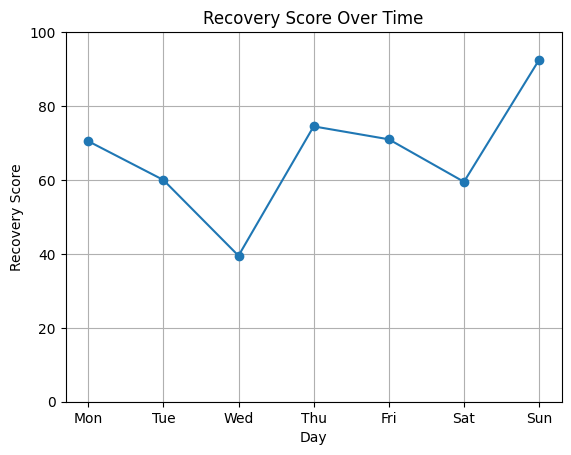

In [5]:
import matplotlib.pyplot as plt

plt.plot(data["day"], data["recovery"], marker='o')
plt.title("Recovery Score Over Time")
plt.xlabel("Day")
plt.ylabel("Recovery Score")
plt.ylim(0, 100)
plt.grid()

plt.show()

## Model Notes

- This is a simplified, interpretable model for recovery scoring
- Constants (8 hours sleep, 10 bpm HR deviation, strain 20) are generalized thresholds
- In a real system, these parameters could be personalized or learned from user data
- The goal is to demonstrate how physiological signals can be translated into actionable insights